# Hotel Booking Cancellation Analysis

## Project Overview
This project analyzes hotel booking data to understand characteristics associated with booking cancellations.

In [1]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the data
df = pd.read_csv('C:/Users/USER/OneDrive/Desktop/Python for Data Analytics and Data Apps/Hotel Booking Analysis/hotel_bookings.csv')

In [3]:
# preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# shape of the dataframe
df.shape

(119390, 32)

In [5]:
#  Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# Check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## Data Cleaning

In [7]:
# Fill Company and Agent with 0(Indicates Booked directly for themselves)
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)

In [8]:
# Fill children with 0
df['children']= df['children'].fillna(0)

In [9]:
# drop the rest of the missing values
df = df.dropna()

In [10]:
# Recheck for missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [11]:
# Fix Data Types
# Convert float to integer
df['children'] = df['children'].astype(int)

In [12]:
# Remove Duplicates
df = df.drop_duplicates()

In [13]:
# export the cleaned data
df.to_csv('cleaned_hotelbooking.csv', index=False)

## Feature Engineering

In [14]:
# Calculate the total_nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [15]:
# Calculate the total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [16]:
#create Is_family (True if there are children or babies, False otherwise)
df['is_family'] = (df['children'] > 0) | (df['babies'] > 0)

In [17]:
# create 'season' based on the arrival month
month_to_season = {
    'December':'Winter', 'January':'Winter', 'February':'Winter', 'March': 'Spring',
      'April': 'Spring', 'May':'Spring', 'June':'Summer', 'July':'Summer', 'August':'Summer',
      'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
    }

df['season'] = df['arrival_date_month'].map(month_to_season)

In [18]:
# preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,False,Summer


## Exploratory Data Analysis (EDA)

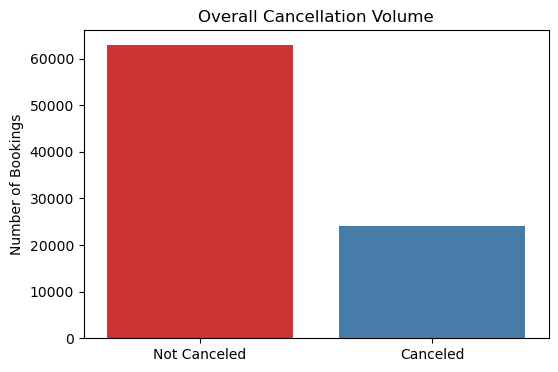

Overall Cancellation Rate: 27.6%


In [19]:
# Overall overall cancellation distribution
plt.figure(figsize=(6,4))
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)
plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

# Calculate the overall cancellation rate
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')


The cancellation rate is 27.6% this means that 1 in 3 bookings is cancelled. Thus the hotels cannot rely on the initial booking numbers for staffing or food ordering. Management must utilize an overbooking strategy to ensure the hotel is full on any given night.

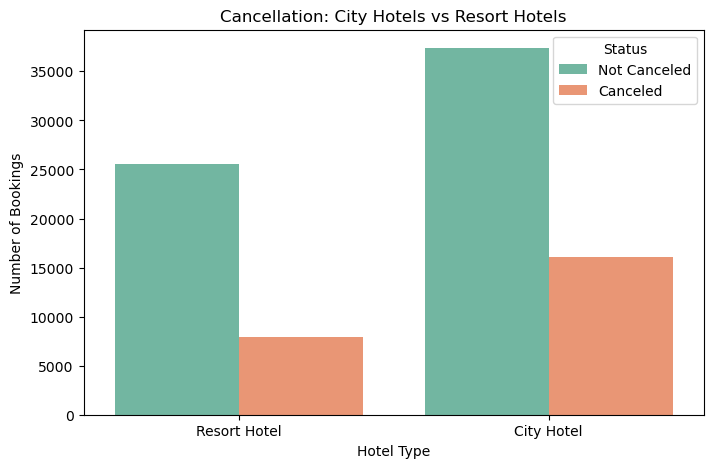

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

In [20]:
# Hotel Type Comparison
# Does the hotel type affect the likelihood of cancellations?
# We will compare the city hotels to resort hotels to see if their customer bases behave differently.
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellation: City Hotels vs Resort Hotels')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotel Type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show()

#Calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize=True) * 100

City hotels see significantly higher booking volumes but they also suffer ffrom a much higher cancellation rate compared to Resort Hotels. City trips are often short, impulsive or tied to business meetings that get moved. Resort trips are usually planned(often flights) making guests less likely to abandon their plans.

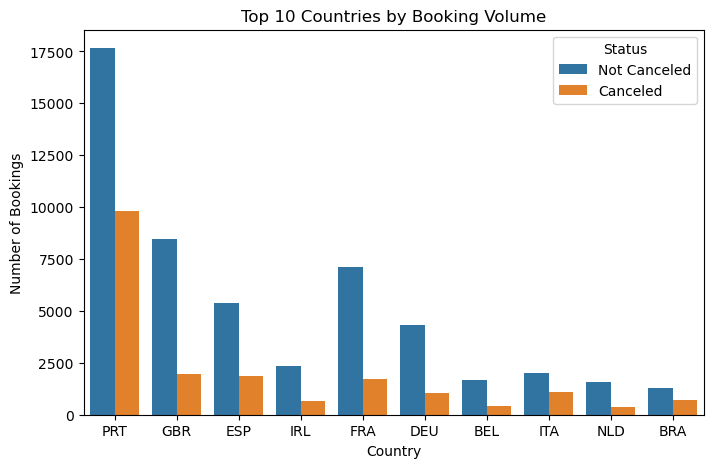

In [21]:
# Understanding geographical origin of our customers
plt.figure(figsize=(8,5))
# Get top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index

sns.countplot(x='country',  hue='is_canceled_label', data=df[df['country'].isin(top_10_countries)])

plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()

PRT(Portugal) generate the highest booking volume of bookings, but it also has a staggering cancellation rate. Because the hotels in this dataset are located in portugal, these are local residents. Locals often book multiple hotels as 'backups' for weekend getaways because they don't have to commit to flights.


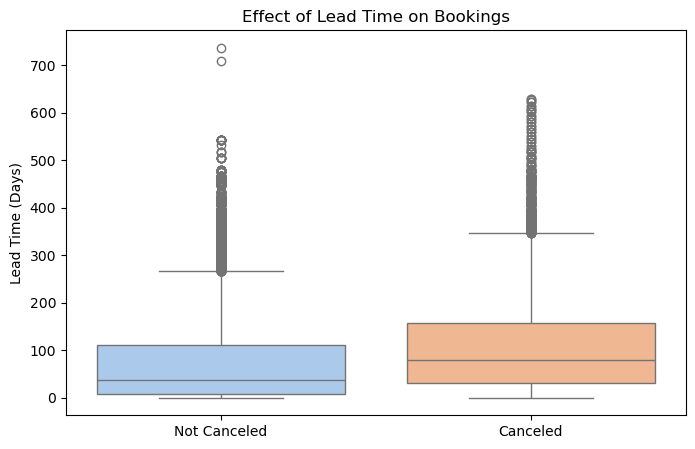

In [22]:
# Lead Time Analysis Leadtime is the number of days between when 
# the guest books and when they arrive.
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data=df, hue='is_canceled_label', 
            palette='pastel',legend=False)
plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The median lead time for canceled bookings is much higher. Simply put: the earlier someone books the more time they have to change their mind, find a better deal, or experience a schedule change.

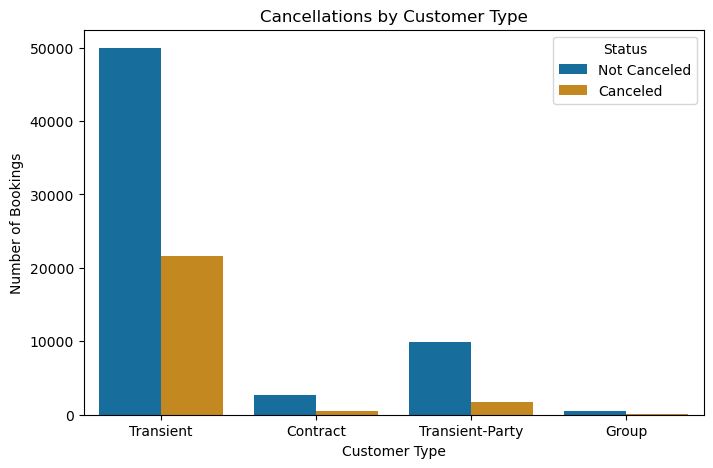

In [23]:
# Customer Type Analysis
# are solo/transient traveller more volatile than large groups or corporate contracts?
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data=df, palette='colorblind')
plt.title('Cancellations by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

'Transient' travelers (independent travelers not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable. Recommendation: The sales team should prioritize securing more B2B (business-to-business) contracts and group events to build a stable, guaranteed revenue base that protects against the volatility of individual transients.

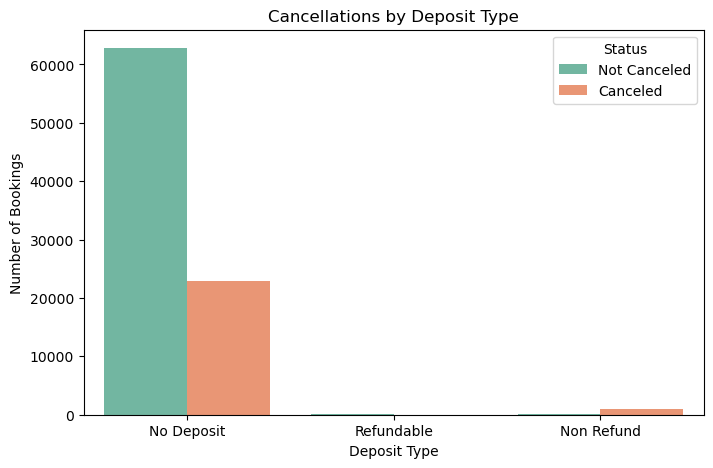

In [24]:
# impact of deposit type on cancellations
plt.figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellations by Deposit Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposittype.png')
plt.show()

The majority of the bookings have no deposit. Management should implement a compulsory and refundable deposit system to minimize the volatility.

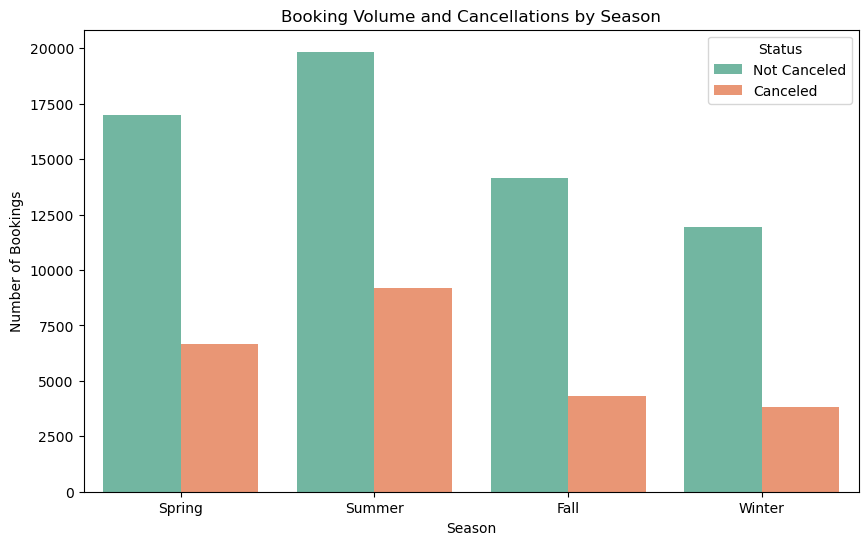

In [25]:
# Seasonal cancellation analysis
plt.figure(figsize=(10,6))

# Define the seasonal order
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

sns.countplot(x='season', hue='is_canceled_label', data=df, order=season_order, palette='Set2')
plt.title('Booking Volume and Cancellations by Season')
plt.ylabel('Number of Bookings')
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()

Summer shows the highest total volume of bookings and the highest absolute number of cancellations.